文件系统---上下文卸载

In [5]:
from langchain.agents import AgentState
from langchain_core.tools import tool
from typing import TypedDict, NotRequired, Annotated


class Todo(TypedDict):
    content: str


def file_reducer(left, right):
    if left is None:
        return right
    elif right is None:
        return left
    else:
        return {**left, **right}


class DeepAgentState(AgentState):
    todos: NotRequired[list[Todo]]
    files: NotRequired[Annotated[dict[str, str], file_reducer]]



In [6]:
from deep_agent_from_search.prompt import LS_DESCRIPTION, READ_FILE_DESCRIPTION, WRITE_FILE_DESCRIPTION
from langgraph.prebuilt import InjectedState
from langchain.tools import InjectedToolCallId
from langgraph.types import Command
from langchain.messages import ToolMessage


@tool(description=LS_DESCRIPTION)
def ls(state: Annotated[DeepAgentState, InjectedState]):
    return list(state.get('files', {}).keys())


@tool(description=READ_FILE_DESCRIPTION)
def read_file(file_path: str, state: Annotated[dict, InjectedState], offset: int = 0, limit: int = 2000):
    files = state.get('files', {})
    if file_path not in files:
        return f"Error:文件{file_path}不存在！"
    content = files[file_path]
    if not content:
        return "System reminder：文件存在但是内容为空！"

    lines = content.splitlines()  #将内容按分割成list
    start_index = offset  #开始行数
    end_index = min(start_index + limit, len(lines))  #结尾行数，最大不能超过总行数

    if start_index >= len(lines):
        return f"Error:偏移量{offset}大于行总数"

    result_lines = []
    for i in range(start_index, end_index):
        line_content = lines[i][:2000]  #获取当前行，最多2000个字符
        result_lines.append(f"{i + 1:6d} \t{line_content}")

    return "\n".join(result_lines)


@tool(description=WRITE_FILE_DESCRIPTION)
def write_file(file_path: str, content: str, state: Annotated[dict, InjectedState],
               tool_call_id: Annotated[str, InjectedToolCallId]):
    files = state.get('files', {})
    files[file_path] = content
    return Command(
        update={
            "files": files,
            "messages": [
                ToolMessage(
                    f"更新文件信息{file_path}", tool_call_id=tool_call_id
                )
            ]
        }
    )


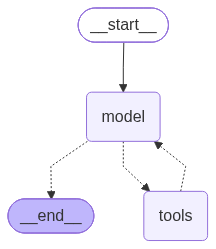

In [7]:
from IPython.display import Image, display
from langchain_openai.chat_models import ChatOpenAI
from langchain.agents import create_agent
from Config.load_key import base_model, base_url, open_key

#文件使用说明
FILE_USAGE_DESCRIPTION = """
你可以访问虚拟文件系统，以帮助您保留和保存上下文
#工作流程
1、**orient**:在开始工作前使用ls()查看现有文件
2、**Save**：使用write_file()存储用户请求，以便我们后续可以保存它
3、**Read**:一旦您对收集到的源内容满意，既可读取保存的文件，并使用它来确保直接回答用户提问
"""

#添加模拟研究指令
SIMPLE_RESEARCH_DESCRIPTION = """重要提示：只需要调用一次网络搜索工具，并使用该工具提供的结果来回答问题"""

search_result = "模型上下文协议（mcp）是有Anthropic开发的一项开放标准协议，旨在实现AI模型与外部系统（如工具，数据库及其他服务）之间的无缝链接。它充当一种标准化的通信层，是AI模型能够以一致且高效的方式访问并利用来自不同来源的数据，从根本上说，MCP通过提供一种统一的数据交换语言，简化了将AI助手与外部服务进行链接的过程"


@tool(description="搜索结果")
def web_search(
        query: str):
    return search_result


model = ChatOpenAI(
    model=base_model,
    base_url=base_url,
    api_key=open_key,
)
agent = create_agent(
    model=model,
    state_schema=DeepAgentState,
    tools=[ls, read_file, write_file, web_search],
    system_prompt=FILE_USAGE_DESCRIPTION + "\n\n" + "=" * 80 + "\n\n" + SIMPLE_RESEARCH_DESCRIPTION
)
display(Image(agent.get_graph().draw_mermaid_png()))

In [8]:
from utils import print_stream_chunk

result = agent.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "帮我总结一下mcp服务的"
            }
        ],
        "files": {}
    }
)
for chunk in result:
    print('===' * 40)
    print_stream_chunk(chunk)


📌 节点：model
🔧 调用工具：ls
   参数：{}
🔧 调用工具：write_file
   参数：{'file_path': 'user_request.txt', 'content': '帮我总结一下mcp服务的'}

📌 节点：tools
🔨 工具结果：ls
   []

📌 节点：tools
🔨 工具结果：write_file
   更新文件信息user_request.txt

📌 节点：model
🔧 调用工具：web_search
   参数：{'query': 'mcp服务是什么'}

📌 节点：tools
🔨 工具结果：web_search
   模型上下文协议（mcp）是有Anthropic开发的一项开放标准协议，旨在实现AI模型与外部系统（如工具，数据库及其他服务）之间的无缝链接。它充当一种标准化的通信层，是AI模型能够以一致且高效的方式访问并利用来自不同来源的数据，从根本上说，MCP通过提供一种统一的数据交换语言，简化了将AI助手与外部服务进行链接的过程

📌 节点：model
🤖 AI：MCP服务（模型上下文协议，Model Context Protocol）是由Anthropic开发的一项开放标准协议，其主要目标是实现AI模型与外部系统（如工具、数据库及其他服务）之间的无缝连接。

MCP的核心作用是充当一种标准化的通信层，使AI模型能够以一致且高效的方式访问并利用来自不同来源的数据。通过提供统一的数据交换语言，MCP简化了将AI助手与各种外部服务集成的过程，从而增强了AI系统的功能性与灵活性。
